# Kiểm thử DBNet++ ONNX Detector

Notebook này nạp mô hình DBNet++ đã được pre-train từ file `data/models/dbnet.onnx` và thử nghiệm khoanh vùng chữ trên các bức ảnh thật của tập ICDAR Detection.

Đã nạp DBNet thành công!


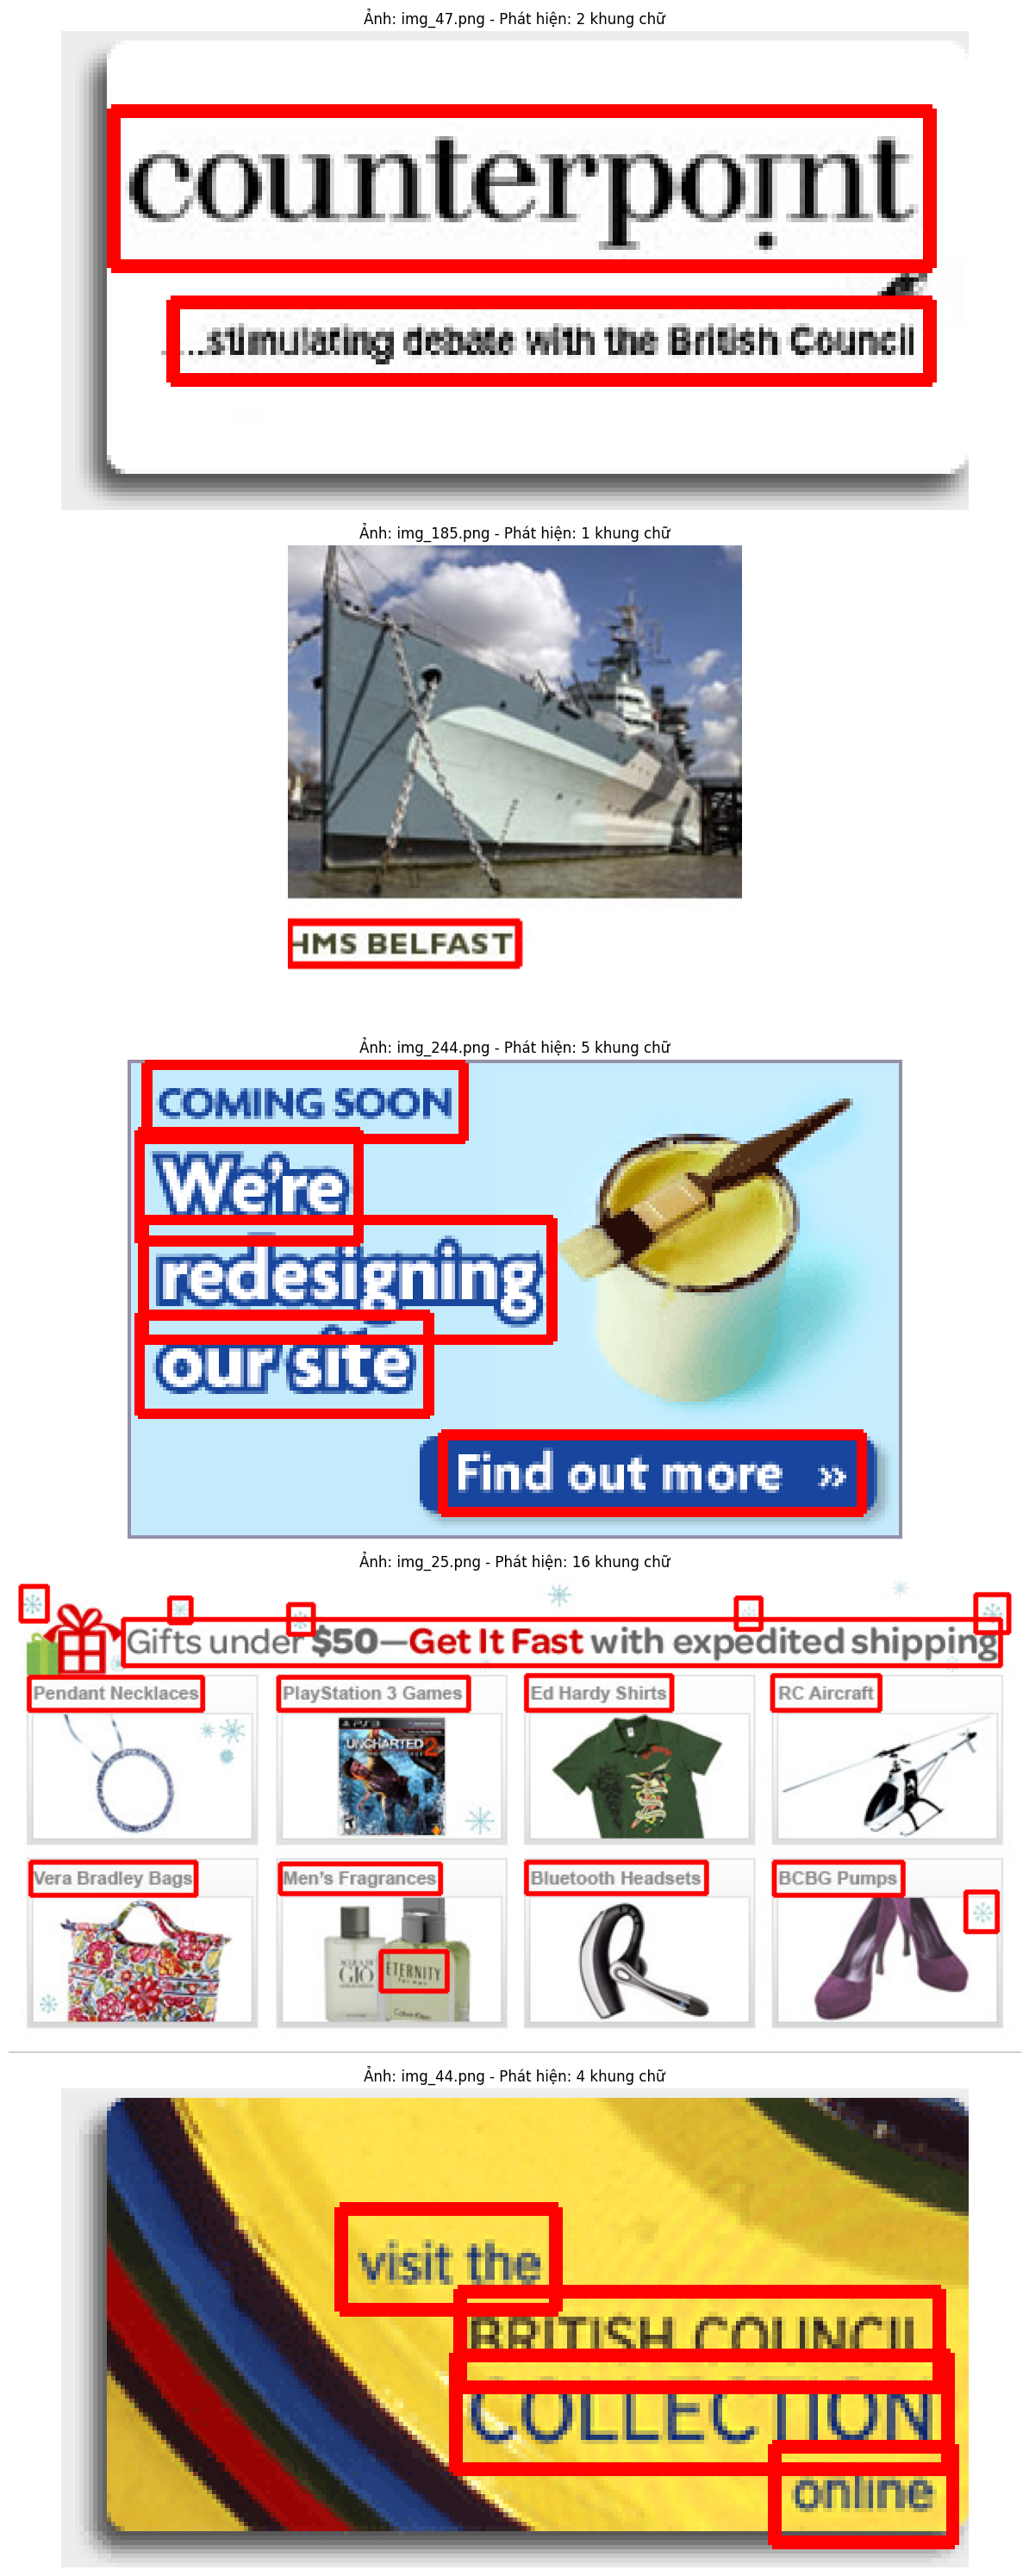

In [1]:
import sys
import os
import glob
import random

# Đổi thư mục làm việc (CWD) về thư mục gốc của project để load đúng file config YAML
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

import cv2
import numpy as np
import matplotlib.pyplot as plt
from src.detector import DBNetDetector

# 1. Load model
detector = DBNetDetector.get_instance('data/models/dbnet.onnx')
print("Đã nạp DBNet thành công!")

# 2. Lấy danh sách ảnh thật từ tập ICDAR Detection
img_files = glob.glob('data/raw/Detection/imgs/*.png') + glob.glob('data/raw/Detection/imgs/*.jpg')
random.seed(42) # Set seed để kết quả ra giống nhau mỗi lần chạy, bạn có thể xóa dòng này để random thực sự
random.shuffle(img_files)

# 3. Chạy test trên 3 ảnh ngẫu nhiên
num_test = 5
plt.figure(figsize=(15, 6 * num_test))

for i in range(num_test):
    img_path = img_files[i]
    img = cv2.imread(img_path)
    
    if img is None:
        continue
        
    # Inference (sẽ tự động áp dụng unclip_ratio=3.0 từ configs/default.yaml)
    boxes = detector.detect(img)
    
    # Vẽ hộp bao lên ảnh
    for b in boxes:
        cv2.rectangle(img, (b.x1, b.y1), (b.x2, b.y2), (0, 0, 255), 2)
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(num_test, 1, i+1)
    plt.imshow(img_rgb)
    plt.title(f"Ảnh: {os.path.basename(img_path)} - Phát hiện: {len(boxes)} khung chữ")
    plt.axis('off')
    
plt.tight_layout()
plt.show()